In [1]:

from keras.layers import Dense
from tensorflow.keras.datasets import fashion_mnist
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers

tf.random.set_seed(42)
(x_train , y_train ) , (x_test , y_test ) = fashion_mnist.load_data ()


x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train[..., None]
x_test = x_test[..., None]

print("Train shape:", x_train.shape)  # (60000, 28, 28, 1)
print("Test shape: ", x_test.shape)

cnn_model = Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1), padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),


    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),

    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')
])

cnn_model.summary()

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"] )

cnn_model.fit(x_train, y_train, validation_split=0.1, epochs=15, batch_size=64)

test_loss, test_acc = cnn_model.evaluate(
x_test, y_test, verbose=0)

print(f"Test Loss: {test_loss:.2f}")
print(f"Test accuracy:, {test_acc*100:.2f}")

Train shape: (60000, 28, 28, 1)
Test shape:  (10000, 28, 28, 1)
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 7, 7, 64)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 3136)              0         
                                                          

313/313 [==============================] - 2s 5ms/step


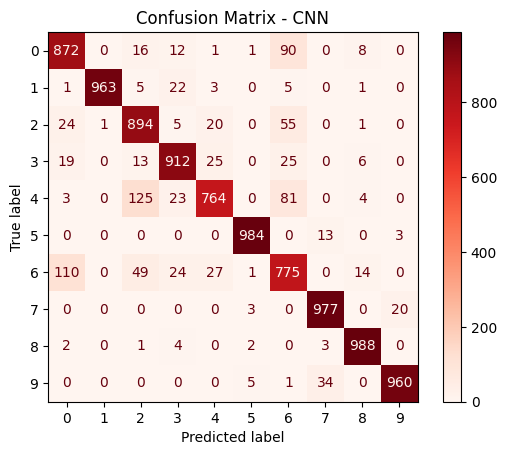

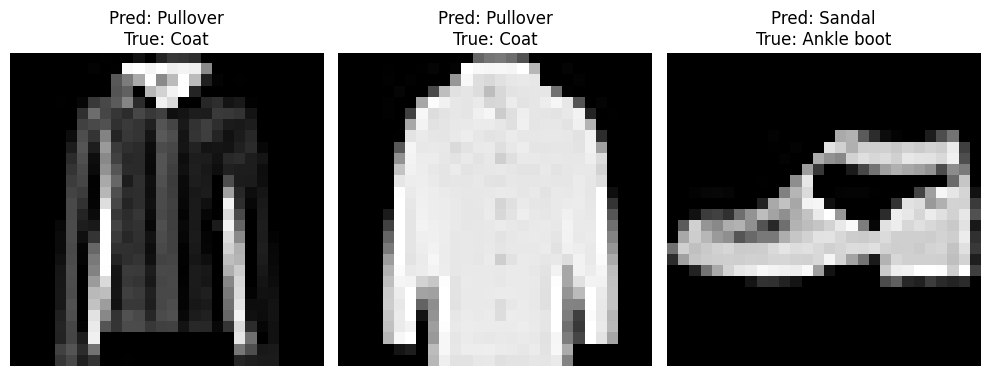

Test Accuracy: 90.89%
Total misclassified: 911


In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import numpy as np


y_pred_probability = cnn_model.predict(x_test)
y_pred = np.argmax(y_pred_probability, axis=1)

confusion_matrix_cnn = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_cnn)
disp.plot(cmap='Reds')
plt.title("Confusion Matrix - CNN")
plt.show()

misclassified_images = np.where(y_pred != y_test)[0]


class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(10, 4))

for i in range(3):
    idx = misclassified_images[i]

    plt.subplot(1, 3, i + 1)
    plt.imshow(x_test[idx].squeeze(), cmap='gray')
    plt.title(f"Pred: {class_names[y_pred[idx]]}\nTrue: {class_names[y_test[idx]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print("Total misclassified:", len(misclassified_images))


# One pattern that I observe within the misclassifications is that is mistaking fashion items that are very close. For example, its predicting a coat to be a pullover which are fairly similar. Additionally, it is predicting an ankle boot to be a sandal, so a common theme that I'm noticing with the misclassifications is that they're almost getting it correct.

# Some realistic ways that I can improve this CNN model is by creating more depth by adding another convolution layer to predict the images, which would allow it to recognize more complex relations and better classify images. Additionally, we could experiment with other optimizers like SGD or AdamW


